In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(42)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 14
})

z          DV/rs           Error          
0.295      7.9417          0.0761         
0.510      12.7210         0.1003         
0.706      16.0506         0.1126         
0.934      19.7213         0.1010         
1.321      24.2531         0.1821         
1.484      26.0647         0.4021         
2.330      31.2687         0.2566         

z_mid: [0.4025 0.608  0.82   1.1275 1.4025 1.907 ]
dTau: [-0.02712354  0.03363642 -0.06134193  0.01058545 -0.00382464  0.31209873]
Err: [0.04906061 0.04149834 0.04994147 0.0541772  0.06114339 0.24127603]


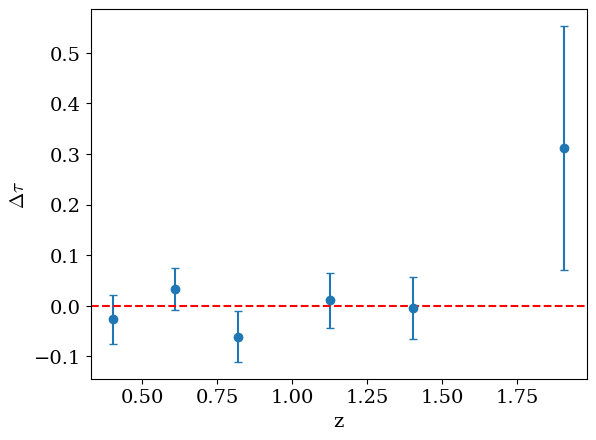

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取数据
z_raw, b_raw, t_raw = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
C_raw = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
m_gpr, C_m_gpr = np.load("output/mB_baomatch_mean_GPR.npy"), np.load("output/mB_baomatch_cov_GPR.npy")
h_gpr, C_h_gpr = np.load("output/cc_baomatch_mean_GPR.npy"), np.load("output/cc_baomatch_cov_GPR.npy")
z_val, b_val = z_raw.astype(float), b_raw.astype(float)

# 2. 统一转换为 DV 数据 (含协方差投影)
z_dv = np.unique(z_val)
b_dv, idx_map = np.zeros(len(z_dv)), np.zeros(len(z_dv), dtype=int)
J = np.zeros((len(z_dv), len(z_val))) # 雅可比矩阵用于投影协方差

print(f"{'z':<10} {'DV/rs':<15} {'Error':<15}")
for i, z in enumerate(z_dv):
    idx = np.where(z_val == z)[0]
    ts = t_raw[idx]
    if 'DV_over_rs' in ts:
        k = idx[np.where(ts == 'DV_over_rs')[0][0]]
        b_dv[i], idx_map[i], J[i, k] = b_val[k], k, 1.0
    else:
        km, kh = idx[np.where(ts == 'DM_over_rs')[0][0]], idx[np.where(ts == 'DH_over_rs')[0][0]]
        b_dv[i] = (z * b_val[kh] * b_val[km]**2)**(1/3) # DV 公式
        J[i, kh], J[i, km] = b_dv[i]/(3*b_val[kh]), 2*b_dv[i]/(3*b_val[km]) # 偏导数
        idx_map[i] = km
    print(f"{z:<10.3f} {b_dv[i]:<15.4f} {np.sqrt((J[i]@C_raw@J[i].T)):<15.4f}")

C_dv = J @ C_raw @ J.T
m, h = m_gpr[idx_map], h_gpr[idx_map]
C_m, C_h = C_m_gpr[np.ix_(idx_map, idx_map)], C_h_gpr[np.ix_(idx_map, idx_map)]

# 3. 差分计算 Delta Tau
K = np.log(10) / 2.5
term = (z_dv[:-1] * (1 + z_dv[1:])**2 * h[1:] * b_dv[1:]**3) / (z_dv[1:] * (1 + z_dv[:-1])**2 * h[:-1] * b_dv[:-1]**3)
d_tau = K * (m[1:] - m[:-1] - 2.5 * np.log10(term))

# 4. 误差传播
W = np.zeros((len(d_tau), len(z_dv)))
np.fill_diagonal(W[:, :-1], -1), np.fill_diagonal(W[:, 1:], 1)
C_tau = (K**2 * W @ C_m @ W.T) + (W @ (C_h / np.outer(h, h)) @ W.T) + (9.0 * W @ (C_dv / np.outer(b_dv, b_dv)) @ W.T)
err_tau = np.sqrt(np.diag(C_tau))

print(f"\nz_mid: {(z_dv[1:]+z_dv[:-1])/2}\ndTau: {d_tau}\nErr: {err_tau}")

plt.errorbar((z_dv[1:]+z_dv[:-1])/2, d_tau, yerr=err_tau, fmt='o', capsize=3)
plt.axhline(0, c='r', ls='--')
plt.ylabel(r'$\Delta \tau$'), plt.xlabel('z')
plt.show()

z          DV/rs           Error          
0.295      7.9417          0.0761         
0.510      12.7210         0.1003         
0.706      16.0506         0.1126         
0.934      19.7213         0.1010         
1.321      24.2531         0.1821         
1.484      26.0647         0.4021         
2.330      31.2687         0.2566         

z_mid: [0.4025 0.608  0.82   1.1275 1.4025 1.907 ]
dTau: [ 0.02358715  0.02934333 -0.10538381  0.14928783 -0.15184712  0.15864298]
Err: [0.0675106  0.07743052 0.12966811 0.12888936 0.09665019 0.31446262]


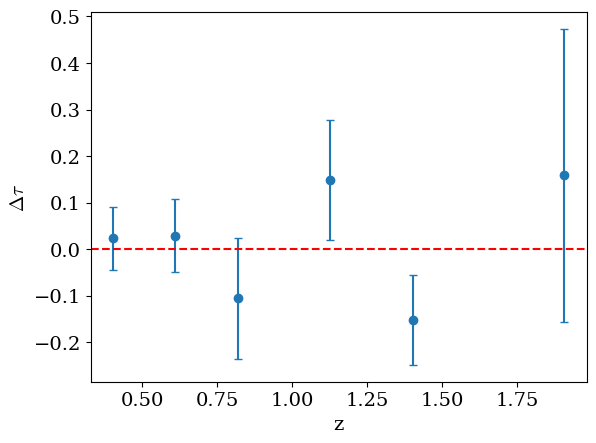

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取数据
z_raw, b_raw, t_raw = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
C_raw = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
m_gpr, C_m_gpr = np.load("output/mB_baomatch_mean_FKM.npy"), np.load("output/mB_baomatch_cov_FKM.npy")
h_gpr, C_h_gpr = np.load("output/cc_baomatch_mean_FKM.npy"), np.load("output/cc_baomatch_cov_FKM.npy")
z_val, b_val = z_raw.astype(float), b_raw.astype(float)

# 2. 统一转换为 DV 数据 (含协方差投影)
z_dv = np.unique(z_val)
b_dv, idx_map = np.zeros(len(z_dv)), np.zeros(len(z_dv), dtype=int)
J = np.zeros((len(z_dv), len(z_val))) # 雅可比矩阵用于投影协方差

print(f"{'z':<10} {'DV/rs':<15} {'Error':<15}")
for i, z in enumerate(z_dv):
    idx = np.where(z_val == z)[0]
    ts = t_raw[idx]
    if 'DV_over_rs' in ts:
        k = idx[np.where(ts == 'DV_over_rs')[0][0]]
        b_dv[i], idx_map[i], J[i, k] = b_val[k], k, 1.0
    else:
        km, kh = idx[np.where(ts == 'DM_over_rs')[0][0]], idx[np.where(ts == 'DH_over_rs')[0][0]]
        b_dv[i] = (z * b_val[kh] * b_val[km]**2)**(1/3) # DV 公式
        J[i, kh], J[i, km] = b_dv[i]/(3*b_val[kh]), 2*b_dv[i]/(3*b_val[km]) # 偏导数
        idx_map[i] = km
    print(f"{z:<10.3f} {b_dv[i]:<15.4f} {np.sqrt((J[i]@C_raw@J[i].T)):<15.4f}")

C_dv = J @ C_raw @ J.T
m, h = m_gpr[idx_map], h_gpr[idx_map]
C_m, C_h = C_m_gpr[np.ix_(idx_map, idx_map)], C_h_gpr[np.ix_(idx_map, idx_map)]

# 3. 差分计算 Delta Tau
K = np.log(10) / 2.5
term = (z_dv[:-1] * (1 + z_dv[1:])**2 * h[1:] * b_dv[1:]**3) / (z_dv[1:] * (1 + z_dv[:-1])**2 * h[:-1] * b_dv[:-1]**3)
d_tau_fkm = K * (m[1:] - m[:-1] - 2.5 * np.log10(term))

# 4. 误差传播
W = np.zeros((len(d_tau_fkm), len(z_dv)))
np.fill_diagonal(W[:, :-1], -1), np.fill_diagonal(W[:, 1:], 1)
C_tau = (K**2 * W @ C_m @ W.T) + (W @ (C_h / np.outer(h, h)) @ W.T) + (9.0 * W @ (C_dv / np.outer(b_dv, b_dv)) @ W.T)
err_tau_fkm = np.sqrt(np.diag(C_tau))

print(f"\nz_mid: {(z_dv[1:]+z_dv[:-1])/2}\ndTau: {d_tau_fkm}\nErr: {err_tau_fkm}")

plt.errorbar((z_dv[1:]+z_dv[:-1])/2, d_tau_fkm, yerr=err_tau_fkm, fmt='o', capsize=3)
plt.axhline(0, c='r', ls='--')
plt.ylabel(r'$\Delta \tau$'), plt.xlabel('z')
plt.show()

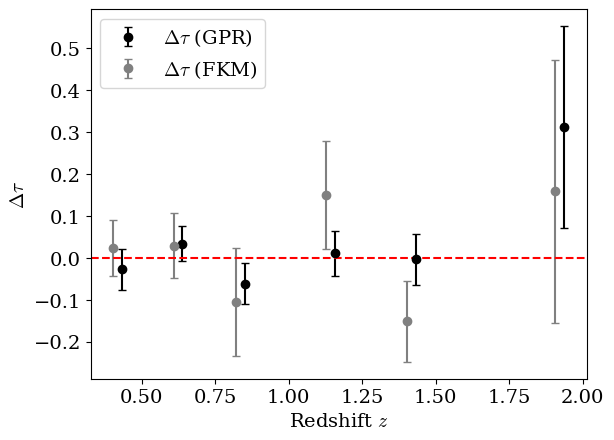

In [4]:
plt.errorbar((z_dv[1:]+z_dv[:-1])/2+0.03, d_tau, yerr=err_tau, color = 'black', fmt='o', capsize=3, label=r'$\Delta \tau$ (GPR)')
plt.errorbar((z_dv[1:]+z_dv[:-1])/2, d_tau_fkm, yerr=err_tau_fkm, color = 'grey', fmt='o', capsize=3, label=r'$\Delta \tau$ (FKM)')
plt.axhline(0, c='r', ls='--')
plt.ylabel(r'$\Delta \tau$'), plt.xlabel('Redshift $z$')
plt.legend()
plt.savefig('fig/delta-tau.pdf')
plt.show()